# ETP shipment lifecycle — model vs display

Single-load **material change ledger** for broker/DS questions: *what moved ETP50, Target 1/3, clocks, quantile refresh, or display workflow?*

**v1 cohort:** HC leadtime-isolated outliers (`leadtime_isolated_ind=1`, `primary_category=LeadtimeChange`).

Set `LOAD_ID` to override rank picker. Canonical example: rank **2** → load **9199475** (+55% avail→48hr, early_burst).


In [9]:
from IPython.display import Markdown, display

import polars as pl

from dqt import resolve_data_dir
from dqt.etp_lake import EtpLake
from dqt.etp_lifecycle import (
    COHORT_HC,
    explain_load,
    resolve_load_id,
    select_outlier_cohort,
)

# --- params ---
COHORT = COHORT_HC  # or "manual"
RANK = 2  # HC rank (9199475)
LOAD_ID = None  # set int to override rank
MIN_SHIFT_PCT = 0.10
TOP_N = 50
QUERY_MDE = False  # True hits Snowflake

data_dir = resolve_data_dir()
lake = EtpLake(data_dir)  # lake root is $DQT_DATA_DIR/etp_lake

hc_index = select_outlier_cohort(
    cohort=COHORT,
    min_shift_pct=MIN_SHIFT_PCT,
    top_n=TOP_N,
    data_dir=data_dir,
)
display(hc_index.select(
    "hc_rank", "loadnumber", "etp50_shift_pct", "path_archetype", "primary_category"
).head(10))

LOAD_ID = resolve_load_id(cohort=COHORT, rank=RANK, load_id=LOAD_ID, data_dir=data_dir)
print(f"Explaining load {LOAD_ID} (cohort={COHORT}, rank={RANK})")


hc_rank,loadnumber,etp50_shift_pct,path_archetype,primary_category
u32,i32,f64,str,str
1,8860433,0.595471,"""late_cliff""","""LeadtimeChange"""
2,8869885,0.554623,"""steady""","""LeadtimeChange"""
3,9199475,0.53527,"""early_burst""","""LeadtimeChange"""
4,8921621,0.493138,"""late_cliff""","""LeadtimeChange"""
5,8920939,0.492003,"""late_cliff""","""LeadtimeChange"""


Explaining load 8869885 (cohort=hc_leadtime_isolated, rank=2)


In [10]:
result = explain_load(lake, LOAD_ID, query_mde=QUERY_MDE, data_dir=data_dir)
payload = result["payload"]
ledger = result["ledger"]
summary = result["summary"]

display(Markdown(f"**Executive summary**\n\n{summary['one_liner']}"))
sh = summary["endpoint_shifts"]
print(
    f"  Model ETP50: ${sh.get('etp50_avail', 0):,.0f} avail → ${sh.get('etp50_48hr', 0):,.0f} @48hr"
    f"  ({sh.get('shift_pct', 0) * 100:+.1f}%)"
)
if summary.get("movement"):
    mv = summary["movement"]
    print(
        f"  Flags: leadtime_isolated={mv.get('leadtime_isolated_ind')}"
        f" clocks_moved={mv.get('clocks_moved_ind')}"
        f" index_clock_overlap={mv.get('index_clock_overlap_ind')}"
    )


**Executive summary**

Load 8869885: LeadtimeChange — Model ETP50 avail→48hr: $+657 (+55.2%) — drivers: model ETP +283 (+19.8%); quantile refresh: ETP +170, knn_50 +124.

  Model ETP50: $1,191 avail → $1,849 @48hr  (+55.2%)


/Users/rarko/Git/Projects/DQT/etp-dqt/src/dqt/etp_timeline.py:775: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  color=color,


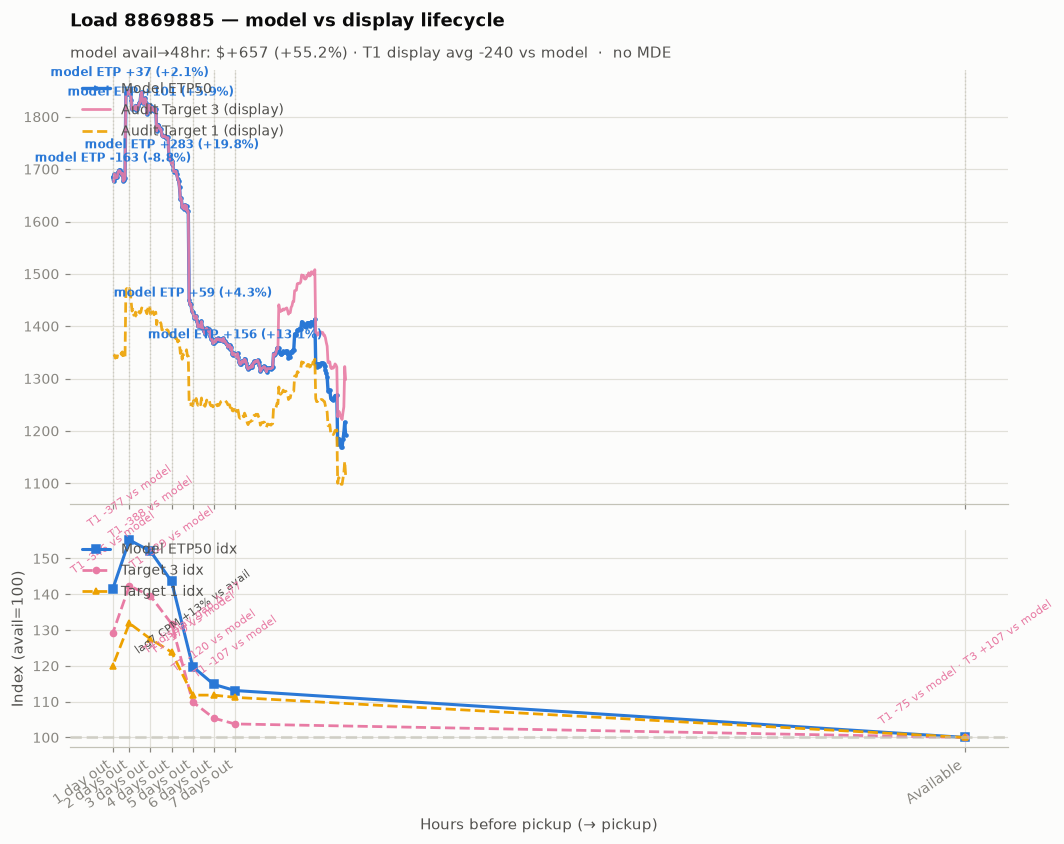

{'loadnumber': 8869885,
 'history': shape: (536, 10)
 ┌────────────┬────────────┬────────┬────────────┬───┬─────────┬────────────┬───────────┬───────────┐
 │ loadnumber ┆ snapshot_u ┆ source ┆ etp10      ┆ … ┆ target3 ┆ hours_befo ┆ hours_sin ┆ ship_mont │
 │ ---        ┆ tc         ┆ ---    ┆ ---        ┆   ┆ ---     ┆ re_pickup  ┆ ce_availa ┆ h         │
 │ i32        ┆ ---        ┆ str    ┆ f64        ┆   ┆ f64     ┆ ---        ┆ ble       ┆ ---       │
 │            ┆ datetime[n ┆        ┆            ┆   ┆         ┆ i32        ┆ ---       ┆ str       │
 │            ┆ s]         ┆        ┆            ┆   ┆         ┆            ┆ i32       ┆           │
 ╞════════════╪════════════╪════════╪════════════╪═══╪═════════╪════════════╪═══════════╪═══════════╡
 │ 8869885    ┆ 2026-05-15 ┆ model  ┆ 1065.31919 ┆ … ┆ null    ┆ 294        ┆ 0         ┆ 2026-05   │
 │            ┆ 12:47:24.2 ┆        ┆ 1          ┆   ┆         ┆            ┆           ┆           │
 │            ┆ 16504      ┆ 

In [11]:
# Timeline chart (model, T1, T3, realized cost)
lake.plot_etp_timeline(LOAD_ID, query_mde=QUERY_MDE)


In [12]:
# Material change ledger — core deliverable
pricing = ledger.filter(pl.col("is_pricing_driver"))
display_ledger = ledger.filter(~pl.col("is_pricing_driver"))

print(f"Pricing drivers: {pricing.height} rows | Display adjustments: {display_ledger.height} rows")
display(
    pricing.select(
        "hours_before_pickup",
        "metric",
        "delta_usd",
        "delta_other",
        "category",
        "confidence",
        "driver_text",
    ).head(30)
)


Pricing drivers: 38 rows | Display adjustments: 32 rows


hours_before_pickup,metric,delta_usd,delta_other,category,confidence,driver_text
i64,str,f64,f64,str,str,str
293,"""etp50""",25.218346,25.41568,"""QuantileRefresh""","""high""","""quantile refresh: ETP +25, knn…"
293,"""book_2_pkup""",null,-0.984284,"""LeadtimeChange""","""high""","""book_2_pkup −1.0h with ETP +25"""
284,"""etp50""",92.980332,89.351603,"""QuantileRefresh""","""high""","""quantile refresh: ETP +93, knn…"
284,"""book_2_pkup""",null,-0.983824,"""LeadtimeChange""","""high""","""book_2_pkup −1.0h with ETP +93"""
284,"""avail_2_book""",null,0.983824,"""LeadtimeChange""","""high""","""avail_2_book +1.0h with ETP +9…"
…,…,…,…,…,…,…
92,"""book_2_pkup""",null,-0.983851,"""LeadtimeChange""","""high""","""book_2_pkup −1.0h with ETP +38"""
92,"""avail_2_book""",null,0.983851,"""LeadtimeChange""","""high""","""avail_2_book +1.0h with ETP +3…"
78,"""etp50""",41.791078,31.135376,"""QuantileRefresh""","""high""","""quantile refresh: ETP +42, knn…"


In [13]:
# Checkpoint table
display(payload["checkpoints"])


loadnumber,mark_hrs,mark_label,etp50,hours_before_pickup,target1,target3,etp50_idx,delta_etp50_prev,target1_idx,t1_gap,target3_idx,t3_gap
i64,i64,str,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64
8869885,999,"""Available""",1191.435198,999,1116.0,1298.0,100.0,-156.253288,100.0,-75.435198,100.0,106.564802
8869885,168,"""7 days out""",1347.688486,168,1241.0,1347.0,113.114711,-20.368335,111.200717,-106.688486,103.775039,-0.688486
8869885,144,"""6 days out""",1368.056821,144,1248.0,1368.0,114.824274,-59.414788,111.827957,-120.056821,105.392912,-0.056821
8869885,120,"""5 days out""",1427.471609,120,1248.0,1427.0,119.811099,-283.192841,111.827957,-179.471609,109.938367,-0.471609
8869885,96,"""4 days out""",1710.66445,96,1382.0,1710.0,143.58015,-100.715174,123.835125,-328.66445,131.74114,-0.66445
8869885,72,"""3 days out""",1811.379623,72,1423.0,1811.0,152.033415,-37.229749,127.508961,-388.379623,139.522342,-0.379623
8869885,48,"""2 days out""",1848.609372,48,1472.0,1848.0,155.158197,163.38228,131.899642,-376.609372,142.372881,-0.609372
8869885,24,"""1 day out""",1685.227092,29,1339.0,1676.0,141.445132,null,119.982079,-346.227092,129.121726,-9.227092


In [14]:
# Decomposition + top hourly steps
decomp = result.get("decompose") or {}
if decomp.get("by_day") is not None:
    display(decomp["by_day"].head(15))
else:
    print("decompose by_day unavailable")
display(payload["top_steps"])


decompose by_day unavailable


loadnumber,snapshot_utc_t0,snapshot_utc_t1,delta_etp50,delta_etp10,prebook_day,lead_day,delta_hours_before_pickup,delta_hours_since_available,delta_total_charges,delta_hard_ft_cnt,delta_hard_ft_cnt_improved,delta_hard_ft_cnt_reg,delta_charge_less_dat,delta_dat_rate,delta_mean_pred_mkt_rt,delta_fuel_cost,delta_fsc,delta_lag7_cpm_x_miles,delta_ra7_cpm_x_miles,delta_book_2_pkup,delta_book_2_pkup_days,delta_avail_2_book,delta_avail_2_book_days,delta_clhp_ma,delta_clhp_pred_line,delta_clhp_pred_tot_cost,delta_knn_50,delta_knn_avg_distance,delta_loaded_miles,delta_miles_feat,ship_month,is_hyperlocal,loaded_miles
i32,datetime[ns],datetime[ns],f64,f64,i64,i64,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i16,f64,str,bool,i16
8869885,2026-05-22 22:03:23.714428,2026-05-22 23:02:26.406276,169.976603,84.836589,7,4,-1,1,0.0,0.0,0.0,0.0,-355.32,0.0,355.32,0.0,0.0,-129.50598,10.610498,-0.984071,0.0,0.984071,0.0,null,39.06752,39.06752,123.936523,0.326648,0,0.0,"""2026-05""",false,564
8869885,2026-05-15 21:39:05.638458,2026-05-15 22:38:07.436803,92.980332,98.222926,0,11,-1,1,0.0,0.0,0.0,0.0,-558.36,0.0,558.36,0.0,0.0,-74.108324,42.789575,-0.983824,0.0,0.983824,0.0,null,0.0,0.0,89.351603,0.066537,0,0.0,"""2026-05""",false,564
8869885,2026-05-16 22:14:52.718175,2026-05-16 23:13:57.120250,84.491819,65.956439,1,10,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-23.733891,32.584212,-0.984557,0.0,0.984557,0.0,null,0.0,0.0,80.54071,0.161729,0,0.0,"""2026-05""",false,564
8869885,2026-05-24 11:27:34.577698,2026-05-24 12:26:37.761181,41.791078,22.283081,9,3,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.984209,0.0,0.984209,0.0,null,-2.2737e-13,0.0,31.135376,0.003087,0,0.0,"""2026-05""",false,564
8869885,2026-05-23 21:40:49.430807,2026-05-23 22:39:51.322216,37.951066,6.129317,8,3,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.923044,-5.938631,-0.983851,0.0,0.983851,0.0,null,8.50671,8.50671,18.417053,-0.008553,0,0.0,"""2026-05""",false,564


In [15]:
# Attribution card (broker one-liner drivers)
for i, row in enumerate(summary["attribution_card"], start=1):
    print(f"{i}. [{row['category']}] {row['driver_text']}")


1. [LeadtimeChange] model ETP +283 (+19.8%)
2. [QuantileRefresh] quantile refresh: ETP +170, knn_50 +124
3. [LeadtimeChange] model ETP -163 (-8.8%)


In [16]:
# Display adjustments (segregated)
display(display_ledger.select("hours_before_pickup", "metric", "driver_text").head(20))


hours_before_pickup,metric,driver_text
i64,str,str
999,"""display""","""T1 -75 vs model · T3 +107 vs m…"
293,"""target1""","""Target 1 +26 (hourly audit sna…"
284,"""target1""","""Target 1 +102 (hourly audit sn…"
273,"""target1""","""Target 1 +26 (hourly audit sna…"
259,"""target1""","""Target 1 +75 (hourly audit sna…"
…,…,…
120,"""display""","""T1 -179 vs model"""
115,"""target1""","""Target 1 +93 (hourly audit sna…"
96,"""target3""","""target3 +283 vs prior checkpoi…"


In [17]:
# Gallery mode — top N HC outliers (optional)
GALLERY = False
if GALLERY:
    for row in hc_index.head(5).iter_rows(named=True):
        ln = int(row["loadnumber"])
        ex = explain_load(lake, ln, data_dir=data_dir)
        print(ex["summary"]["one_liner"])
else:
    print("Set GALLERY=True to iterate top HC outliers")


Set GALLERY=True to iterate top HC outliers


## Lightning cost tracking

Ledger rows with `Lightning` in `driver_text` — CLHP endpoint, path checkpoint, and hourly moves.
Threshold defaults: **$50 abs OR 10% rel** (see `notebooks/etp-slider/lightning-cost-threshold.ipynb`).


In [ ]:
lightning = result.get("lightning") or {}
print("Endpoint summary:", lightning.get("endpoint_summary"))
lt_rows = ledger.filter(pl.col("driver_text").str.contains("Lightning"))
print(f"Lightning ledger rows: {lt_rows.height}")
display(lt_rows.select(
    "hours_before_pickup", "metric", "delta_usd", "delta_other", "category", "driver_text"
).head(20))
